<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter03_Statistical_Experiments_and_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Statistical Experiments and Significance Testing

## Tujuan Chapter

Pada chapter ini kita mempelajari bagaimana melakukan eksperimen statistik dan menguji apakah suatu hasil benar-benar signifikan atau hanya terjadi secara kebetulan.

Topik yang dipelajari:

1. A/B Testing
2. Hypothesis Testing
3. Null Hypothesis
4. Alternative Hypothesis
5. p-value
6. Type I Error
7. Type II Error
8. Permutation Test
9. Statistical Significance
10. Multiple Testing

Konsep-konsep ini digunakan secara luas dalam:

- Data Science
- Machine Learning
- Business Analytics
- Product Experimentation
- Medical Research

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Dataset A/B Testing

Misalkan sebuah perusahaan ingin membandingkan performa dua halaman website.

Group A = halaman lama

Group B = halaman baru

In [2]:
group_A = np.random.normal(
    loc=50,
    scale=10,
    size=100
)

group_B = np.random.normal(
    loc=55,
    scale=10,
    size=100
)

# Statistik Dasar

In [3]:
print("Mean A :", np.mean(group_A))
print("Mean B :", np.mean(group_B))

Mean A : 48.96153482605907
Mean B : 55.223045870499234


# Visualisasi Data

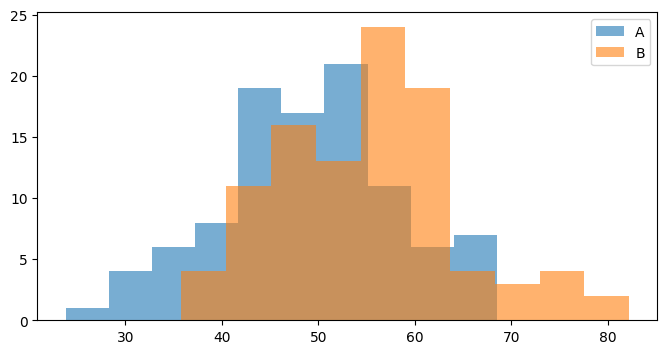

In [4]:
plt.figure(figsize=(8,4))

plt.hist(
    group_A,
    alpha=0.6,
    label="A"
)

plt.hist(
    group_B,
    alpha=0.6,
    label="B"
)

plt.legend()

plt.show()

# 1. A/B Testing

A/B Testing adalah eksperimen yang membandingkan dua versi untuk menentukan mana yang lebih baik.

In [5]:
difference = np.mean(group_B) - np.mean(group_A)

print(difference)

6.261511044440162


# Interpretasi

Perbedaan rata-rata menunjukkan peningkatan performa pada Group B.

# 2. Hypothesis Testing

Tujuan hypothesis testing adalah menentukan apakah perbedaan yang diamati cukup kuat secara statistik.

## Null Hypothesis (H0)

Tidak ada perbedaan antara kedua grup.

\[
H_0:\mu_A=\mu_B
\]

## Alternative Hypothesis (H1)

Ada perbedaan antara kedua grup.

\[
H_1:\mu_A\neq\mu_B
\]

# 3. Two-Sample t-Test

Digunakan untuk membandingkan rata-rata dua kelompok.

In [6]:
t_stat, p_value = stats.ttest_ind(
    group_A,
    group_B
)

print("t-statistic =", t_stat)
print("p-value =", p_value)

t-statistic = -4.7546959435052765
p-value = 3.8191352626795345e-06


# Interpretasi p-value

Jika:

\[
p < 0.05
\]

maka hasil dianggap signifikan.

In [7]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


# 4. Significance Level

Tingkat signifikansi biasanya:

\[
\alpha = 0.05
\]

atau 5%.

# Mengapa 5%?

Karena secara historis dianggap sebagai batas yang wajar untuk mengurangi kesalahan pengambilan keputusan.

# 5. Type I Error

Type I Error terjadi ketika:

- H0 benar
- tetapi ditolak

Disebut juga False Positive.

In [8]:
print("Probability Type I Error =", alpha)

Probability Type I Error = 0.05


# 6. Type II Error

Type II Error terjadi ketika:

- H0 salah
- tetapi gagal ditolak

Disebut juga False Negative.

# Contoh Type II Error

Produk baru sebenarnya lebih baik, tetapi hasil eksperimen gagal mendeteksinya.

# 7. Permutation Test

Permutation Test adalah metode non-parametrik untuk menguji signifikansi.

In [9]:
combined = np.concatenate(
    [group_A, group_B]
)

observed_diff = (
    np.mean(group_B)
    -
    np.mean(group_A)
)

print(observed_diff)

6.261511044440162


# Simulasi Permutation

In [10]:
permutation_diffs = []

for _ in range(1000):

    shuffled = np.random.permutation(
        combined
    )

    new_A = shuffled[:100]
    new_B = shuffled[100:]

    diff = (
        np.mean(new_B)
        -
        np.mean(new_A)
    )

    permutation_diffs.append(diff)

In [11]:
permutation_diffs = np.array(
    permutation_diffs
)

# Visualisasi Permutation Distribution

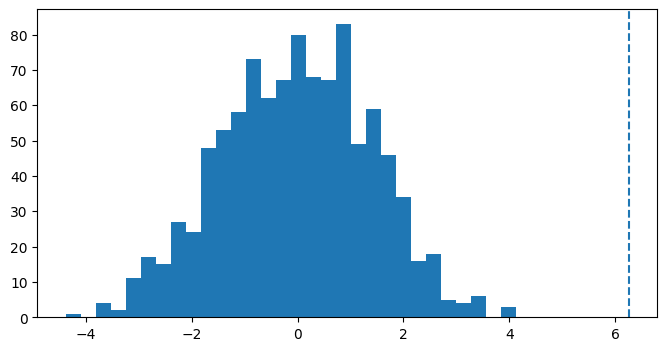

In [12]:
plt.figure(figsize=(8,4))

plt.hist(
    permutation_diffs,
    bins=30
)

plt.axvline(
    observed_diff,
    linestyle="--"
)

plt.show()

# Menghitung Permutation p-value

In [13]:
perm_p = np.mean(
    np.abs(permutation_diffs)
    >=
    np.abs(observed_diff)
)

print(perm_p)

0.0


# Interpretasi

Semakin kecil p-value, semakin kuat bukti terhadap H0.

# 8. Confidence Interval Difference

In [14]:
mean_diff = (
    np.mean(group_B)
    -
    np.mean(group_A)
)

se = np.sqrt(
    np.var(group_A)/len(group_A)
    +
    np.var(group_B)/len(group_B)
)

lower = mean_diff - 1.96*se
upper = mean_diff + 1.96*se

print(lower)
print(upper)

3.6933037804901874
8.829718308390138


# Interpretasi Confidence Interval

Interval ini menunjukkan rentang kemungkinan nilai sebenarnya dari perbedaan rata-rata.

# 9. Statistical vs Practical Significance

Statistical significance tidak selalu berarti perbedaan tersebut penting secara bisnis.

In [15]:
small_effect_A = np.random.normal(
    100,
    10,
    10000
)

small_effect_B = np.random.normal(
    100.5,
    10,
    10000
)

stats.ttest_ind(
    small_effect_A,
    small_effect_B
)

TtestResult(statistic=np.float64(-3.918919405500811), pvalue=np.float64(8.92428956431415e-05), df=np.float64(19998.0))

# Interpretasi

Dengan sampel yang sangat besar, perbedaan kecil pun dapat menjadi signifikan secara statistik.

# 10. Multiple Testing Problem

Semakin banyak pengujian dilakukan, semakin besar peluang menemukan hasil signifikan secara kebetulan.

In [16]:
p_values = np.random.uniform(
    0,
    1,
    100
)

significant = np.sum(
    p_values < 0.05
)

print(significant)

7


# Bonferroni Correction

Salah satu solusi:

\[
\alpha_{new}
=
\frac{\alpha}{m}
\]

dimana:

m = jumlah pengujian

In [17]:
alpha = 0.05
m = 100

bonferroni_alpha = alpha / m

print(bonferroni_alpha)

0.0005


# Mengapa Penting?

Machine Learning sering melakukan banyak eksperimen sekaligus sehingga risiko false positive meningkat.

# Ringkasan Chapter 3

Pada chapter ini dipelajari:

- A/B Testing
- Null Hypothesis
- Alternative Hypothesis
- t-Test
- p-value
- Type I Error
- Type II Error
- Permutation Test
- Confidence Interval
- Multiple Testing
- Bonferroni Correction

Konsep-konsep ini menjadi fondasi evaluasi model, eksperimen produk, dan penelitian berbasis data.

# Persiapan Chapter Berikutnya

Pada Chapter 4 kita akan mempelajari:

- Simple Linear Regression
- Multiple Linear Regression
- Residual Analysis
- Prediction
- Model Evaluation

yang menjadi dasar sebagian besar algoritma machine learning modern.